### Pacotes importados

In [2]:
using LinearAlgebra
using Printf

## Chapter 10: Newton's local method

### Algorithm 10.1: Newton's local method

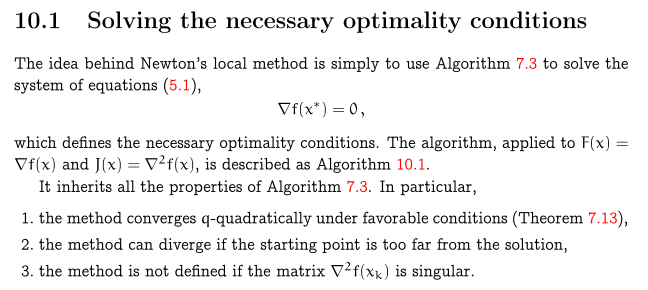

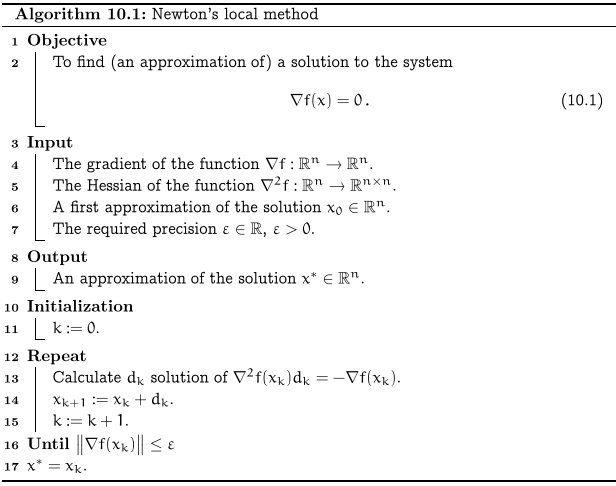

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$; $x_0 = [1.0, 1.0]$

In [3]:
# Definição da função, gradiente e hessiana do Exemplo 5.8
f58(x) = x[2] + x[1]*cos(x[2])
grad_f58(x) = [cos(x[2]), 1 - x[1]*sin(x[2])]
hess_f58(x) = [0 -sin(x[2]); -sin(x[2]) -x[1]*cos(x[2])]

function algoritmo_10_1(grad, hess, x0, epsilon)
    xk = Float64.(x0)
    k = 0
    println("k   | xk                   | ||grad f(xk)||")
    println("-"^50)
    
    while norm(grad(xk)) > epsilon
        gk = grad(xk)
        Hk = hess(xk)
        
        @printf("%-3d | [%.4f, %.4f] | %.15e\n", k, xk[1], xk[2], norm(gk))
        
        # Passo de Newton: Hk * dk = -gk
        try
            dk = Hk \ -gk
            xk = xk + dk
            k += 1
        catch e
            println("Erro: Hessiana singular ou erro numérico na iteração $k")
            return xk
        end
        
        if k > 50 break end
    end
    @printf("%-3d | [%.4f, %.4f] | %.15e\n", k, xk[1], xk[2], norm(grad(xk)))
    return xk
end

println("Executando Algoritmo 10.1 (Exemplo 5.8):")
algoritmo_10_1(grad_f58, hess_f58, [1.0, 1.0], 1e-15)

Executando Algoritmo 10.1 (Exemplo 5.8):
k   | xk                   | ||grad f(xk)||
--------------------------------------------------
0   | [1.0000, 1.0000] | 5.630790622854015e-01
1   | [0.7761, 1.6421] | 2.368271197155362e-01
2   | [0.9986, 1.5707] | 1.416724341603416e-03
3   | [1.0000, 1.5708] | 7.305823747692860e-09
4   | [1.0000, 1.5708] | 6.123233995736766e-17


2-element Vector{Float64}:
 1.0
 1.5707963267948966

### Algorithm 10.2: Newton's local method by quadratic modeling

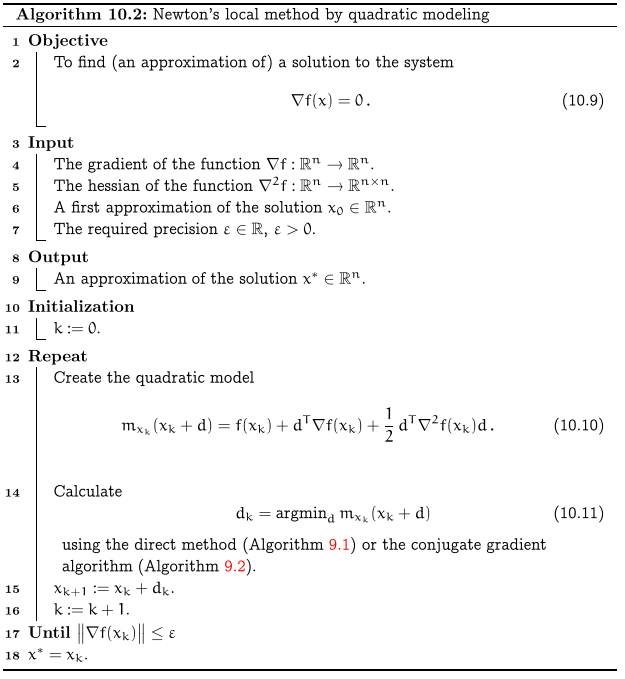

We test the algorithm on the Rosenbrock function. It is described in Section 11.6 of the book for two variables.  The implementation below involves $n$ variables: \\[f(x) = \sum_{i=1}^{n-1} f_i(x) = \sum_{i=1}^{n-1} 100 (x_{i+1}-x_i^2)^2 + (1-x_i)^2.\\]
The calculation of the derivatives is based on the partial derivatives of the functions $f_i$:
\\[
\begin{array}{rcl}
\partial f_i/\partial x_i&=& -400 x_i (x_{i+1}-x_i^2) - 2(1-x_i), \\\\
\partial f_i/\partial x_{i+1}&=& 200 (x_{i+1}-x_i^2), \\\\
\partial^2 f_i/\partial x^2_i  &=& -400 x_{i+1}+ 1200 x_i^2 + 2, \\\\
\partial^2 f_i/\partial x_i \partial x_{i+1}  &=& -400 x_i^2, \\\\
\partial^2 f_i/\partial x^2_{i+1}  &=& 200. 
\end{array}
\\]

In [4]:
function rosenbrock_grad(x)
    n = length(x)
    g = zeros(n)
    for i in 1:n-1
        g[i] += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] += 200*(x[i+1] - x[i]^2)
    end
    return g
end

function rosenbrock_hess(x)
    n = length(x)
    H = zeros(n, n)
    for i in 1:n-1
        H[i, i] += -400*x[i+1] + 1200*x[i]^2 + 2
        H[i, i+1] = -400*x[i]
        H[i+1, i] = -400*x[i]
        H[i+1, i+1] += 200
    end
    return H
end

println("Executando Newton na Função de Rosenbrock (x0=[0,0]):")
# Newton Local (10.1/10.2) na Rosenbrock
algoritmo_10_1(rosenbrock_grad, rosenbrock_hess, [0.0, 0.0], 1e-8)

Executando Newton na Função de Rosenbrock (x0=[0,0]):
k   | xk                   | ||grad f(xk)||
--------------------------------------------------
0   | [0.0000, 0.0000] | 2.000000000000000e+00
1   | [1.0000, 0.0000] | 4.472135954999579e+02
2   | [1.0000, 1.0000] | 0.000000000000000e+00


2-element Vector{Float64}:
 1.0
 1.0

We now apply the algorithm on example 5.8. In this case, the algorithm fails to converge, and one hessian is not positive definite. We try first using the direct method to solve the quadratic problem. An error is triggered. 

In [5]:
function tentativa_cholesky_58(x0)
    xk = Float64.(x0)
    gk = grad_f58(xk)
    Hk = hess_f58(xk)
    
    println("Tentando resolver Hk * d = -gk via Cholesky...")
    try
        # O Algoritmo 9.1 exige Cholesky (Matriz Definida Positiva)
        L = cholesky(Hk).L
        dk = L' \ (L \ -gk)
        println("Passo calculado: ", dk)
    catch e
        println("ERRO DISPARADO: Hessiana não é Definida Positiva (SDP).")
        println("Detalhe: ", e)
    end
end

tentativa_cholesky_58([1.0, 1.0])

Tentando resolver Hk * d = -gk via Cholesky...
ERRO DISPARADO: Hessiana não é Definida Positiva (SDP).
Detalhe: PosDefException(1)


If we try with the conjugate gradient method, an error is also triggered. 

In [6]:
function tentativa_gc_58(x0)
    xk = Float64.(x0)
    gk = grad_f58(xk)
    Hk = hess_f58(xk)
    
    println("Tentando resolver Hk * d = -gk via Gradiente Conjugado...")
    try
        # Algoritmo 9.2 (GC) também falha se Hk não for SDP
        dk = gradiente_conjugado(Hk, gk, [0.0, 0.0]) # Usando sua função GC anterior
    catch e
        println("ERRO DISPARADO: Gradiente Conjugado falhou (Hessiana indefinida).")
    end
end

# Nota: Para rodar este, a função 'gradiente_conjugado' do bloco anterior deve estar na memória.
tentativa_gc_58([1.0, 1.0])

Tentando resolver Hk * d = -gk via Gradiente Conjugado...
ERRO DISPARADO: Gradiente Conjugado falhou (Hessiana indefinida).
